In [1]:
from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import re
import unicodedata
from transformers import AutoTokenizer,AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report
from accelerate import Accelerator, notebook_launcher
from torch.optim import AdamW
import gc
import matplotlib.pyplot as plt


2026-02-23 10:50:12.107365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771843812.301305      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771843812.360365      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771843812.826210      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771843812.826248      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771843812.826251      24 computation_placer.cc:177] computation placer alr

In [2]:
pd.set_option("display.max_colwidth", None)

In [3]:
ds = load_dataset("winvoker/turkish-sentiment-analysis-dataset")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/76.1M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/440679 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48965 [00:00<?, ? examples/s]

In [4]:
ds.column_names

{'train': ['text', 'label', 'dataset'], 'test': ['text', 'label', 'dataset']}

In [5]:
train = ds["train"]
test = ds["test"]

In [6]:
ds.set_format(type="pandas")

In [7]:
train_df = ds["train"][:]
test_df = ds["test"][:]

In [8]:
train_df.describe()

,text,label,dataset
count,440679,440679,440679
unique,440058,3,6
top,Memnun kaldık.,Positive,urun_yorumlari
freq,17,235949,210693


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440679 entries, 0 to 440678
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     440679 non-null  object
 1   label    440679 non-null  object
 2   dataset  440679 non-null  object
dtypes: object(3)
memory usage: 10.1+ MB


In [10]:
train_df.head(5)

,text,label,dataset
0,ürünü hepsiburadadan alalı 3 hafta oldu. orjinal ve eksiksiz şekilde geldi. şarj konusunda 1 günü rahat çıkarıyor oyun oynamama rağmen. teslimat sürecide hızlı gerçekleşti. en uygun fiyata iphone kalitesi kaçırmayın..,Positive,urun_yorumlari
1,"ürünlerden çok memnunum, kesinlikle herkese tavsiye ederim. ayrıca hepsiburada ya süper hızlı gönderim için teşekkür ederim.",Positive,urun_yorumlari
2,"hızlı kargo, temiz alışveriş.teşekkür ederim.",Positive,urun_yorumlari
3,Çünkü aranan tapınak bu bölgededir .,Notr,wiki
4,bu telefonu başlıca alma nedenlerim ise elimdeki samsung j5 artık yetersiz gelmesi. nedemlerim;,Positive,urun_yorumlari


<Axes: xlabel='label', ylabel='Count'>

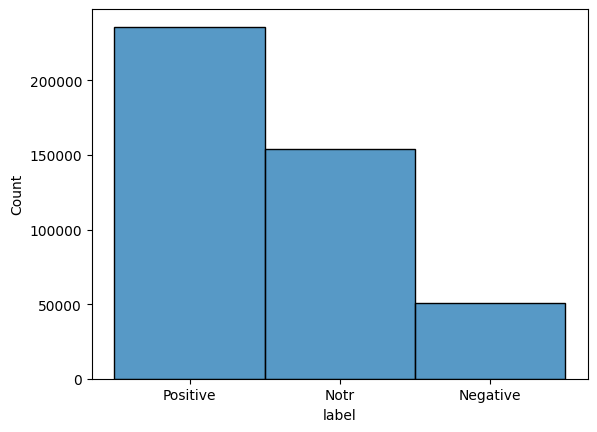

In [11]:
sns.histplot(train_df, x="label")

In [12]:
train_df["counts"] = train_df["text"].apply(lambda x: len(re.findall(r"[^a-zA-Z0-9çÇğĞıİüÜöÖşŞ?.,\s]", x)))

In [13]:
train_df.loc[224469, "text"]

"black decker kali̇tesi̇nden emi̇n olduğum bi̇r marka. uzun zamandir da matkabini kullaniyorum. i̇nşaallah avuç taşlama maki̇nesi̇ni̇ de uzun yillar kullanirim. tavsi̇ye ederi̇m. hb' ye de teşekkürler."

In [14]:
pattern = r"[^a-zA-Z0-9çÇğĞıİüÜöÖşŞ?!.,\s]"

text = train_df.loc[224469, "text"]

[(m.group(), m.start()) for m in re.finditer(pattern, text)]

[('̇', 17),
 ('̇', 22),
 ('̇', 31),
 ('̇', 44),
 ('̇', 96),
 ('̇', 123),
 ('̇', 128),
 ('̇', 131),
 ('̇', 165),
 ('̇', 174),
 ("'", 180)]

In [15]:
for c in train_df.loc[224469, "text"][:30]:
    print(c, ord(c))

b 98
l 108
a 97
c 99
k 107
  32
d 100
e 101
c 99
k 107
e 101
r 114
  32
k 107
a 97
l 108
i 105
̇ 775
t 116
e 101
s 115
i 105
̇ 775
n 110
d 100
e 101
n 110
  32
e 101
m 109


In [16]:
len(train_df.sort_values(by="counts", ascending=False).query("counts>10")["counts"])

3830

In [17]:
unicode_normalize = pd.DataFrame()
unicode_normalize["text"] = train_df["text"].apply(lambda x: unicodedata.normalize("NFC", x))
unicode_normalize["counts"] = unicode_normalize["text"].apply(lambda x: len(re.findall(r"[^a-zA-Z0-9çÇğĞıİüÜöÖşŞ?.,\s]", x)))
len(unicode_normalize.query("counts>10"))

3830

In [18]:
def fix_i(text):
    text = text.replace("i̇", "i")
    text = text.replace("İ", "İ")
    return text

In [19]:
replace_i = pd.DataFrame()
replace_i["text"] = train_df["text"].apply(fix_i)
replace_i["counts"] = replace_i["text"].apply(lambda x: len(re.findall(r"[^a-zA-Z0-9çÇğĞıİüÜöÖşŞ?.!,\s]", x)))
len(replace_i.query("counts>10"))

1181

In [20]:
text = replace_i.loc[224469, "text"]
for c in text[:50]:
    print(c, ord(c))

b 98
l 108
a 97
c 99
k 107
  32
d 100
e 101
c 99
k 107
e 101
r 114
  32
k 107
a 97
l 108
i 105
t 116
e 101
s 115
i 105
n 110
d 100
e 101
n 110
  32
e 101
m 109
i 105
n 110
  32
o 111
l 108
d 100
u 117
ğ 287
u 117
m 109
  32
b 98
i 105
r 114
  32
m 109
a 97
r 114
k 107
a 97
. 46
  32


In [21]:
def del_comb(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if not unicodedata.combining(c)
    )

In [22]:
del_combined = pd.DataFrame()
del_combined["text"] = train_df["text"].apply(del_comb)
del_combined["counts"] = del_combined["text"].apply(lambda x: len(re.findall(r"[^a-zA-Z0-9çÇğĞıİüÜöÖşŞ?.!,\s]", x)))
len(del_combined.query("counts>10"))

1172

In [23]:
text = del_combined.loc[224469, "text"]
for c in text[:50]:
    print(c, ord(c))

b 98
l 108
a 97
c 99
k 107
  32
d 100
e 101
c 99
k 107
e 101
r 114
  32
k 107
a 97
l 108
i 105
t 116
e 101
s 115
i 105
n 110
d 100
e 101
n 110
  32
e 101
m 109
i 105
n 110
  32
o 111
l 108
d 100
u 117
g 103
u 117
m 109
  32
b 98
i 105
r 114
  32
m 109
a 97
r 114
k 107
a 97
. 46
  32


In [24]:
del_combined.sort_values(by="counts").query("counts>50")

text  \
162413                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [25]:
replace_i.sort_values(by="counts").query("counts>45")

text  \
159062                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [26]:
train_df["text"] = train_df["text"].apply(fix_i)
train_df = train_df.query("counts<=50")

In [27]:
train_df.reset_index(drop=True, inplace=True)

In [28]:
train_df.shape

(440610, 4)

In [29]:
train_df.columns

Index(['text', 'label', 'dataset', 'counts'], dtype='object')

In [30]:
train_df.drop(["counts","dataset"], axis=1, inplace=True)

In [31]:
test_df["text"] = test_df["text"].apply(fix_i)

In [32]:
test_df.shape

(48965, 3)

In [33]:
test_df.reset_index(drop=True, inplace=True)

In [34]:
test_df.columns

Index(['text', 'label', 'dataset'], dtype='object')

In [35]:
test_df.drop("dataset", axis=1, inplace=True)

In [36]:
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

In [37]:
train_val = train_ds.train_test_split(test_size=0.05)
train_ds, val_ds = train_val["train"], train_val["test"]

In [38]:
train_ds.features

{'text': Value('string'), 'label': Value('string')}

In [39]:
def tokenize_func(example):
    return tokenizer(example["text"], truncation=True)

In [40]:
label2id = {
    "Negative": 0,
    "Notr": 1,
    "Positive": 2
}
id2label = {v: k for k, v in label2id.items()}

In [41]:
checkpoint = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, 
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
train_ds[1]

{'text': 'Merhaba, konuyla ilgili yardımcı olmak isteriz. İrtibat numaranızı direkt mesaj olarak bize iletir misiniz?',
 'label': 'Positive'}

In [43]:
tokenized_train = train_ds.map(tokenize_func, batched=True)
tokenized_test = test_ds.map(tokenize_func, batched=True)

Map:   0%|          | 0/418579 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

In [44]:
tokenized_train.features

{'text': Value('string'),
 'label': Value('string'),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [45]:
tokenized_train = tokenized_train.remove_columns("text")
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_train.set_format("torch")
tokenized_train.features

{'labels': Value('string'),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [46]:
tokenized_test.features

{'text': Value('string'),
 'label': Value('string'),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [47]:
tokenized_test = tokenized_test.remove_columns("text")
tokenized_test = tokenized_test.rename_column("label", "labels")
tokenized_test.set_format("torch")
tokenized_test.features

{'labels': Value('string'),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [48]:
train_val = tokenized_train.train_test_split(test_size=0.05)
train_val

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 397650
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20929
    })
})

In [49]:
tokenized_train, tokenized_val = train_val["train"], train_val["test"]
tokenized_train.shape

(397650, 4)

In [50]:
tokenized_val.shape

(20929, 4)

In [51]:
tokenized_train = tokenized_train.map(
    lambda x: {"labels": [label2id[label] for label in x["labels"]]},
    batched=True
)

tokenized_test = tokenized_test.map(
    lambda x: {"labels": [label2id[label] for label in x["labels"]]},
    batched=True
)

Map:   0%|          | 0/397650 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

In [52]:
tokenized_train["labels"]

Column([tensor(2), tensor(1), tensor(2), tensor(2), tensor(2), ...])

In [53]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_data_loader = DataLoader(tokenized_train, shuffle=True, batch_size=32, collate_fn=data_collator)
val_data_loader = DataLoader(tokenized_val, batch_size=32, collate_fn=data_collator)
test_data_loader = DataLoader(tokenized_test, batch_size=32, collate_fn=data_collator)

In [54]:
for batch in train_data_loader:
    break

In [55]:
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 270]),
 'token_type_ids': torch.Size([32, 270]),
 'attention_mask': torch.Size([32, 270])}

In [56]:
output = model(**batch)

In [57]:
output

SequenceClassifierOutput(loss=tensor(1.1940, grad_fn=<NllLossBackward0>), logits=tensor([[-0.5169, -0.5822,  0.1307],
        [-0.7088, -0.5680,  0.1710],
        [-0.7035, -0.6813,  0.1407],
        [-0.5583,  0.0334,  0.2496],
        [-0.7581, -0.5458,  0.1242],
        [-0.5366,  0.0402,  0.2482],
        [-0.6122, -0.6152,  0.1391],
        [-0.7288, -0.6513,  0.1266],
        [-0.7274, -0.3722,  0.3283],
        [-0.7068, -0.3738,  0.2784],
        [ 0.1539, -0.4838,  0.2959],
        [-0.5922,  0.0186,  0.2149],
        [-0.7470, -0.4825,  0.2496],
        [-0.2567, -0.2413,  0.0535],
        [-0.5169,  0.1006,  0.1684],
        [-0.8382, -0.4470,  0.2083],
        [-0.7230, -0.4141,  0.2579],
        [-0.5522, -0.0037,  0.2760],
        [-0.5855,  0.0789,  0.2339],
        [-0.3730, -0.4635,  0.1394],
        [-0.5594, -0.0878,  0.2312],
        [-0.8135, -0.4491,  0.2764],
        [-0.5535,  0.0122,  0.2021],
        [-0.5712,  0.0064,  0.1985],
        [-0.5500,  0.0590,  0.2

In [58]:
torch.softmax(output.logits, dim=1)

tensor([[0.2599, 0.2435, 0.4966],
        [0.2192, 0.2523, 0.5284],
        [0.2300, 0.2351, 0.5349],
        [0.1980, 0.3578, 0.4442],
        [0.2149, 0.2658, 0.5193],
        [0.2011, 0.3581, 0.4408],
        [0.2429, 0.2422, 0.5149],
        [0.2256, 0.2438, 0.5307],
        [0.1887, 0.2691, 0.5422],
        [0.1971, 0.2750, 0.5279],
        [0.3730, 0.1971, 0.4299],
        [0.1967, 0.3624, 0.4409],
        [0.1995, 0.2599, 0.5405],
        [0.2959, 0.3005, 0.4036],
        [0.2067, 0.3832, 0.4101],
        [0.1877, 0.2776, 0.5346],
        [0.1989, 0.2708, 0.5303],
        [0.1992, 0.3448, 0.4560],
        [0.1919, 0.3728, 0.4353],
        [0.2791, 0.2550, 0.4659],
        [0.2080, 0.3334, 0.4586],
        [0.1847, 0.2659, 0.5493],
        [0.2045, 0.3601, 0.4354],
        [0.2024, 0.3606, 0.4370],
        [0.1994, 0.3666, 0.4340],
        [0.2022, 0.3642, 0.4336],
        [0.1951, 0.2785, 0.5264],
        [0.1888, 0.3683, 0.4429],
        [0.1894, 0.2615, 0.5491],
        [0.221

In [59]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [60]:
num_epoch = 2
total_len = len(train_data_loader) * num_epoch
optimizer = AdamW(model.parameters(), lr=5e-5)
lr_scheduler = get_scheduler(
    "linear",
    num_training_steps=total_len,
    optimizer=optimizer,
    num_warmup_steps=0
)

In [61]:
train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

In [62]:
train_ds = train_ds.map(
    lambda x: {"labels": [label2id[label] for label in x["labels"]]},
    batched=True
)

val_ds = val_ds.map(
    lambda x: {"labels": [label2id[label] for label in x["labels"]]},
    batched=True
)

test_ds = test_ds.map(
    lambda x: {"labels": [label2id[label] for label in x["labels"]]},
    batched=True
)

Map:   0%|          | 0/418579 [00:00<?, ? examples/s]

Map:   0%|          | 0/22031 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

In [63]:
def train_and_evaluate(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=3e-5)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True)

    tokenized_train = train_ds.map(tokenize_function, batched=True)
    tokenized_val = val_ds.map(tokenize_function, batched=True)
    tokenized_test = test_ds.map(tokenize_function, batched=True)

    cols_to_keep = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in tokenized_train.column_names:
        cols_to_keep.append("token_type_ids")
        
    tokenized_train.set_format("torch", columns=cols_to_keep)
    tokenized_val.set_format("torch", columns=cols_to_keep)
    tokenized_test.set_format("torch", columns=cols_to_keep)


    train_data_loader = DataLoader(
        tokenized_train, 
        shuffle=True, 
        batch_size=16, 
        collate_fn=data_collator
    )
    val_data_loader = DataLoader(
        tokenized_val,
        batch_size=16,
        collate_fn=data_collator
    )
    test_data_loader = DataLoader(
        tokenized_test,
        batch_size=16,
        collate_fn=data_collator
    )

    total_len = num_epoch*len(train_data_loader)
    lr_scheduler = get_scheduler(
        "linear",
        optimizer,
        num_warmup_steps=0, 
        num_training_steps=total_len
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "steps": []
    }

    global_step = 0

    
    with tqdm(total=total_len, unit="sentence") as pbar:
        for epoch in range(num_epoch):
            model.train()
            for batch in train_data_loader:
                batch = {k: v.to(device) for k,v in batch.items()}
                output = model(**batch)
                loss = output.loss
                
                loss.backward()
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
                pbar.update(1)

                preds = output.logits.argmax(dim=-1)
                train_acc = accuracy_score(batch["labels"].cpu().numpy(), preds.cpu().numpy())
                history["train_loss"].append(loss.item())
                history["train_acc"].append(train_acc)
                global_step += 1
                
                
            model.eval()
            val_preds = []
            val_labels = []
            val_total_loss = 0
            
            for batch in val_data_loader:
                batch = {k: v.to(device) for k,v in batch.items()}
                with torch.no_grad():
                    output = model(**batch)
                    
                val_total_loss += output.loss.item()
    
                logits = output.logits
                preds = torch.argmax(logits, dim=1)
                labels = batch["labels"]
    
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

            avg_val_loss = val_total_loss / len(val_data_loader)
            val_f1 = f1_score(val_labels, val_preds, average="macro")
            val_acc = accuracy_score(val_labels, val_preds)
            print(f"""Epoch {epoch+1} Validation set
                        loss: {avg_val_loss:.4f}
                        f1 score: {val_f1}
                        Accuracy Score: {val_acc}""")

            history["val_loss"].append(avg_val_loss)
            history["val_acc"].append(val_acc)
            history["val_f1"].append(val_f1)
            history["steps"].append(global_step)


    test_preds = []
    test_labels = []
    for batch in test_data_loader:
        batch = {k: v.to(device) for k,v in batch.items()}
        with torch.no_grad():
            output = model(**batch)
    
        logits = output.logits
        preds = torch.argmax(logits, dim=1)
        labels = batch["labels"]
    
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
    
    test_f1 = f1_score(test_labels, test_preds, average="macro")
    test_acc = accuracy_score(test_labels, test_preds)
    print(f"""Test set
                f1 score: {test_f1}
                Accuracy Score: {test_acc}""")
            

    safe_model_name = model_name.replace("/", "_")
    save_path = f"./saved_models/{safe_model_name}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"Kaydedildi: {save_path}")
    
    print(f"--- Temizleniyor: {model_name} ---")
    
    del model
    del tokenizer

    gc.collect()
    
    torch.cuda.empty_cache() 
    
    print("GPU Hafızası temizlendi.\n")

    return {
        "Model":model_name,
        "Accuracy": test_acc,
        "F1 Score": test_f1,
        "True Labels": test_labels,
        "Predictions": test_preds,
        "History": history
    }
                

In [64]:
def visualize_history(history):
    plt.figure(figsize=(16, 6))
    
    total_steps = len(history["train_loss"])
    window_size = max(10, total_steps // 20) 
    
    # --- Grafik 1: Loss ---
    plt.subplot(1, 2, 1)
    
    plt.plot(history["train_loss"], alpha=0.10, color="blue", label="Raw Train Loss")
    
    train_loss_s = pd.Series(history["train_loss"]).rolling(window=window_size, min_periods=1).mean()
    plt.plot(train_loss_s, color="blue", linewidth=2.5, label=f"Train Loss (Avg {window_size})")
    
    plt.plot(history["steps"], history["val_loss"], color="red", marker="o", markersize=8, linestyle="--", linewidth=2, label="Validation Loss")
    
    plt.title("Eğitim ve Doğrulama Kaybı (Loss)")
    plt.xlabel("Adımlar (Steps)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # --- Grafik 2: Accuracy ---
    plt.subplot(1, 2, 2)
    
    plt.plot(history["train_acc"], alpha=0.10, color="green", label="Raw Train Acc")
    
    train_acc_s = pd.Series(history["train_acc"]).rolling(window=window_size, min_periods=1).mean()
    plt.plot(train_acc_s, color="green", linewidth=2.5, label=f"Train Acc (Avg {window_size})")
    
    plt.plot(history["steps"], history["val_acc"], color="orange", marker="s", markersize=8, linestyle="--", linewidth=2, label="Validation Accuracy")
    
    plt.title("Eğitim ve Doğrulama Başarısı (Accuracy)")
    plt.xlabel("Adımlar (Steps)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [65]:
model_names = [
    "dbmdz/bert-base-turkish-cased",
    "xlm-roberta-base",
    "dbmdz/distilbert-base-turkish-cased",
]
benchmark_results = []

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/418579 [00:00<?, ? examples/s]

Map:   0%|          | 0/22031 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

  0%|          | 0/52324 [00:00<?, ?sentence/s]

Epoch 1 Validation set
                        loss: 0.0803
                        f1 score: 0.9522139358094254
                        Accuracy Score: 0.9729018201624983
Epoch 2 Validation set
                        loss: 0.0802
                        f1 score: 0.955566199105736
                        Accuracy Score: 0.9747174436021969
Test set
                f1 score: 0.9570160556471664
                Accuracy Score: 0.9756765036250383
Kaydedildi: ./saved_models/dbmdz_bert-base-turkish-cased
--- Temizleniyor: dbmdz/bert-base-turkish-cased ---
GPU Hafızası temizlendi.



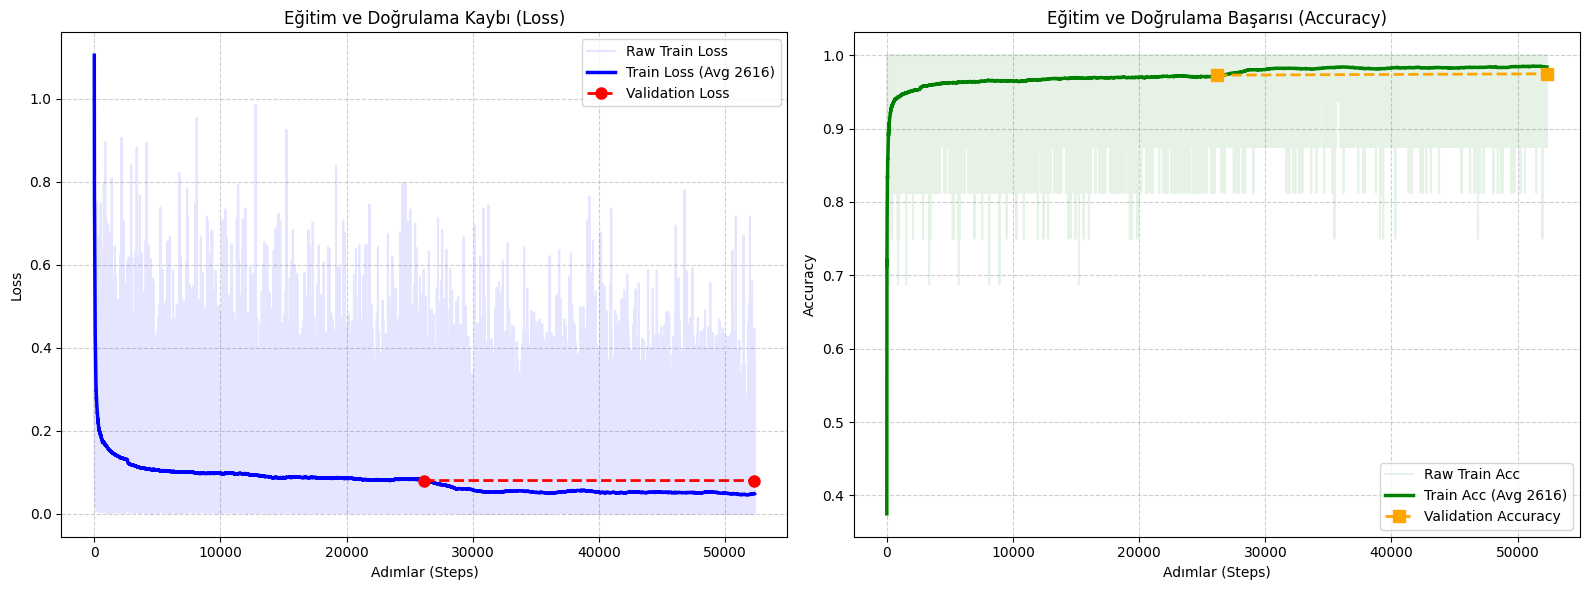

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

Map:   0%|          | 0/418579 [00:00<?, ? examples/s]

Map:   0%|          | 0/22031 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

  0%|          | 0/52324 [00:00<?, ?sentence/s]

Epoch 1 Validation set
                        loss: 0.0956
                        f1 score: 0.935986309444884
                        Accuracy Score: 0.9637329217920203
Epoch 2 Validation set
                        loss: 0.0862
                        f1 score: 0.9449807951508827
                        Accuracy Score: 0.9690436203531387
Test set
                f1 score: 0.9479562986309836
                Accuracy Score: 0.9707750433983457
Kaydedildi: ./saved_models/xlm-roberta-base
--- Temizleniyor: xlm-roberta-base ---
GPU Hafızası temizlendi.



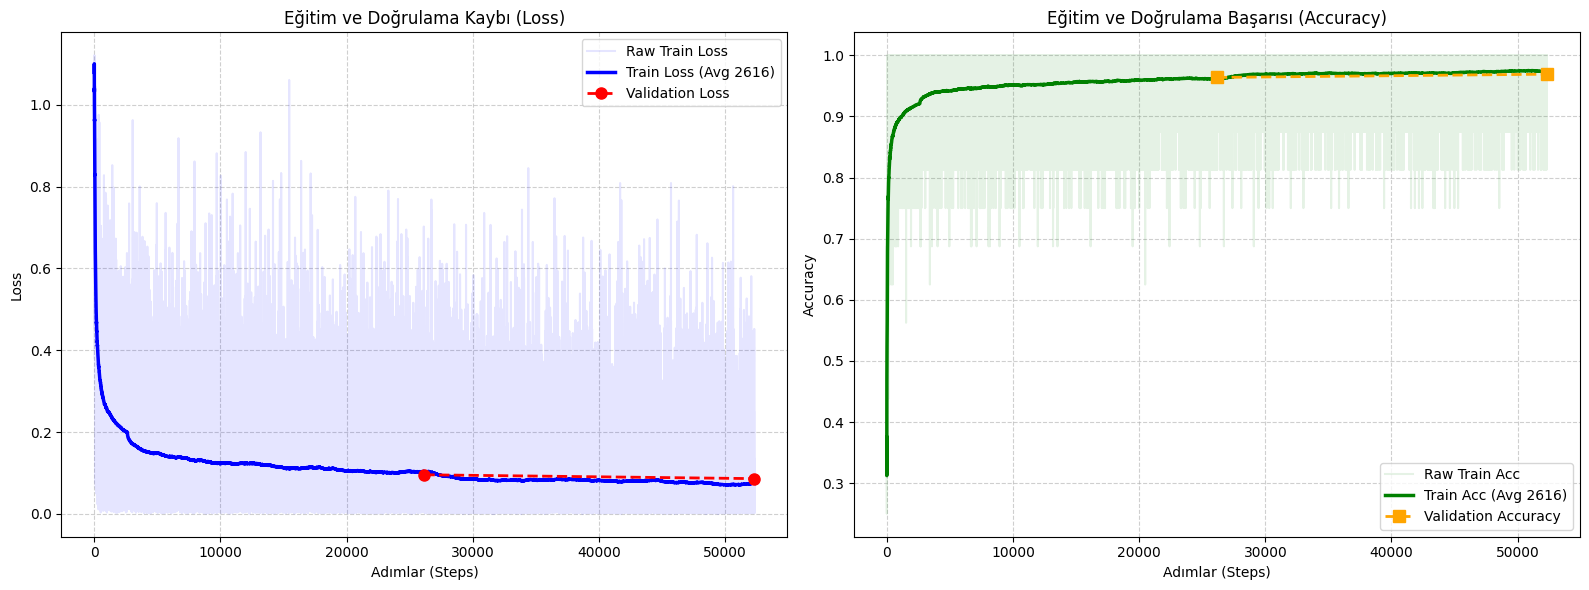

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/410 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/273M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at dbmdz/distilbert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/418579 [00:00<?, ? examples/s]

Map:   0%|          | 0/22031 [00:00<?, ? examples/s]

Map:   0%|          | 0/48965 [00:00<?, ? examples/s]

  0%|          | 0/52324 [00:00<?, ?sentence/s]

Epoch 1 Validation set
                        loss: 0.0913
                        f1 score: 0.9434706212212008
                        Accuracy Score: 0.9679088557033271
Epoch 2 Validation set
                        loss: 0.0891
                        f1 score: 0.9456561974378775
                        Accuracy Score: 0.9693159638690936
Test set
                f1 score: 0.948079823528334
                Accuracy Score: 0.9706320841417339
Kaydedildi: ./saved_models/dbmdz_distilbert-base-turkish-cased
--- Temizleniyor: dbmdz/distilbert-base-turkish-cased ---
GPU Hafızası temizlendi.



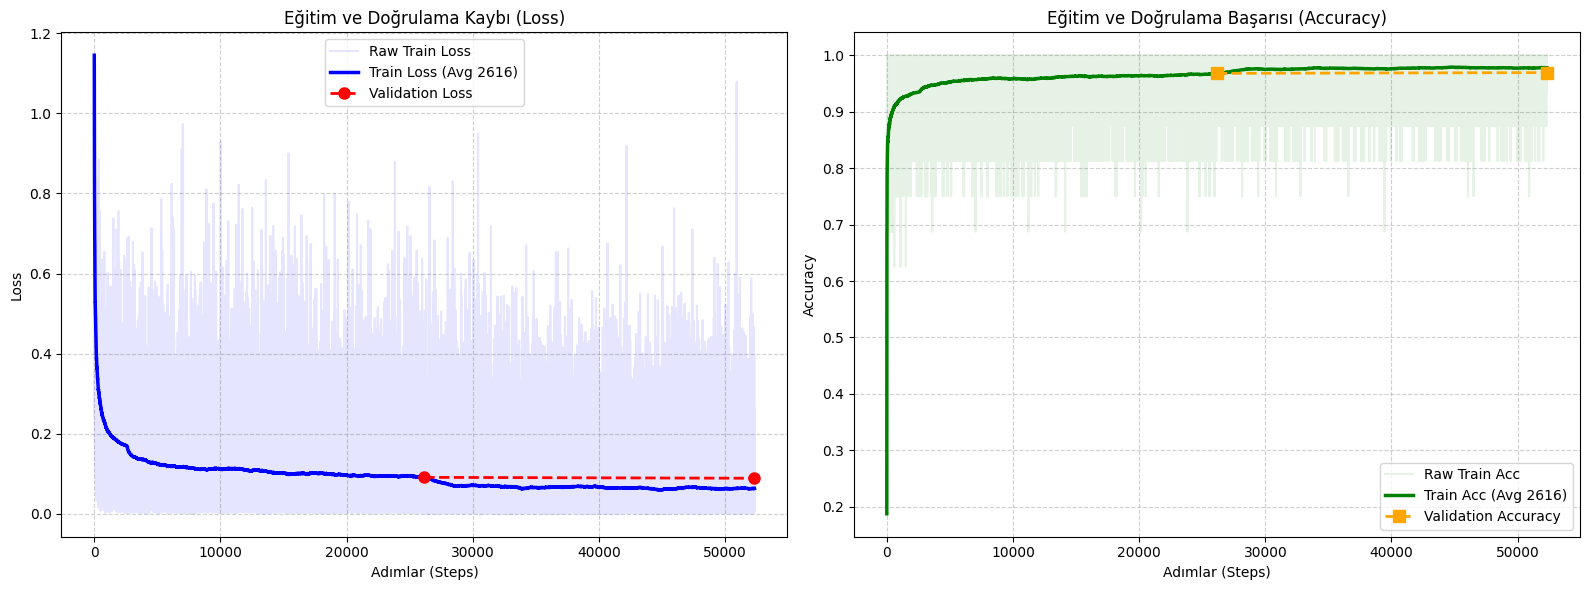

In [66]:
for model_name in model_names:
    try:
        result = train_and_evaluate(model_name)
        benchmark_results.append(result)
        visualize_history(result["History"])
    except Exception as e:
        print(f"{model_name} modelinde hata: {e}")
        torch.cuda.empty_cache()
        gc.collect()

/tmp/ipykernel_24/3003656471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="F1 Score", data=res_df, palette="viridis")


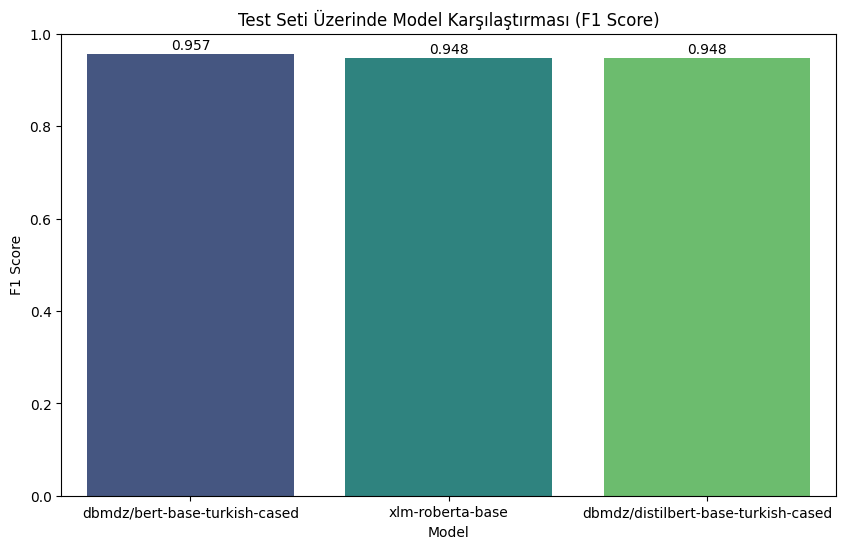


--- dbmdz/bert-base-turkish-cased Test Raporu ---
              precision    recall  f1-score   support

     Olumsuz       0.92      0.87      0.89      5656
        Nötr       1.00      1.00      1.00     17092
      Olumlu       0.97      0.98      0.98     26217

    accuracy                           0.98     48965
   macro avg       0.96      0.95      0.96     48965
weighted avg       0.98      0.98      0.98     48965


--- xlm-roberta-base Test Raporu ---
              precision    recall  f1-score   support

     Olumsuz       0.90      0.84      0.87      5656
        Nötr       1.00      1.00      1.00     17092
      Olumlu       0.97      0.98      0.97     26217

    accuracy                           0.97     48965
   macro avg       0.96      0.94      0.95     48965
weighted avg       0.97      0.97      0.97     48965


--- dbmdz/distilbert-base-turkish-cased Test Raporu ---
              precision    recall  f1-score   support

     Olumsuz       0.90      0.85    

In [67]:
if benchmark_results:
    res_df = pd.DataFrame(benchmark_results)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Model", y="F1 Score", data=res_df, palette="viridis")
    plt.title("Test Seti Üzerinde Model Karşılaştırması (F1 Score)")
    plt.ylim(0, 1.0)
    for i, row in res_df.iterrows():
        plt.text(i, row["F1 Score"]+0.01, f'{row["F1 Score"]:.3f}', ha="center")
    plt.savefig("benchmark_test_results.png")
    plt.show()
    
    for res in benchmark_results:
        print(f"\n--- {res['Model']} Test Raporu ---")
        print(classification_report(res['True Labels'], res['Predictions'], target_names=["Olumsuz", "Nötr", "Olumlu"]))

In [68]:
# import torch
# print(torch.cuda.device_count())

In [69]:
# def accelerator_train():
#     accelerator = Accelerator()
#     model = AutoModelForSequenceClassification.from_pretrained(
#         checkpoint, 
#         num_labels=3,
#         id2label=id2label,
#         label2id=label2id
#     )
#     optimizer = AdamW(model.parameters(), lr=3e-3)

#     train_dl, eval_dl, model, optimizer = accelerator.prepare(
#        train_data_loader, val_data_loader, model, optimizer
#     )

#     num_epoch = 3
#     total_len = len(train_dl)*num_epoch
#     lr_scheduler = get_scheduler(
#         "linear",
#         optimizer,
#         num_training_steps = total_len,
#         num_warmup_steps=0
#     )

    
#     print("Num processes:", accelerator.num_processes)
#     print("Device:", accelerator.device)
#     print("Is main process:", accelerator.is_main_process)
#     print("Local rank:", accelerator.local_process_index)

#     progress_bar = tqdm(range(total_len), disable=not accelerator.is_main_process)

#     model.train()
#     for epoch in range(num_epoch):
#         for batch in train_dl:
#             outputs = model(**batch)
#             loss = outputs.loss

#             accelerator.backward()
#             optimizer.step()
#             lr_scheduler.step()
#             optimizer.zero_grad()

#             progress_bar.update(1)
    

In [70]:
# notebook_launcher(accelerator_train, num_processes=2)